In [1]:
import matplotlib.pyplot as plt

import numpy as np
import anndata as ad
import polars as pl
import sys

import src as scit

/home/aleksander-work/Skrivbord/pyproject/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
rep1_s = "~/Dokument/fragments/mutant/rep1"
rep2_s = "~/Dokument/fragments/mutant/rep2"

dm6 = scit.tl.get_genome_dict('DM6')
rep1ac = scit.ld.fragments(
    f"{rep1_s}/H3K27ac/fragments.tsv",
    dm6,
    ignore_missing_chr=True
)
rep2ac = scit.ld.fragments(
    f"{rep2_s}/H3K27ac/fragments.tsv",
    dm6,
    ignore_missing_chr=True
)


Info: Reading fragments file with 4696807 lines...
Info: Number of unique barcodes is 62175...
Info: Found no chromosomes starting with 'chr' in fragments. Mapping chromosome names with lambda x: 'chr' + x. If you want to avoid this, set chr_name_insert_prefix = False
Info: Ignoring chromosomes ['chr211000022278760' 'chr211000022280328'
 'chrUnmapped_Scaffold_8_D1580_D1567']


100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 225/225 [00:16<00:00, 13.44it/s]


Info: Reading fragments file with 5385854 lines...
Info: Number of unique barcodes is 53233...
Info: Found no chromosomes starting with 'chr' in fragments. Mapping chromosome names with lambda x: 'chr' + x. If you want to avoid this, set chr_name_insert_prefix = False
Info: Ignoring chromosomes ['chr211000022278760' 'chr211000022280328'
 'chrUnmapped_Scaffold_8_D1580_D1567']


100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 225/225 [00:17<00:00, 12.61it/s]


In [3]:
rep1me = scit.ld.fragments(
    f"{rep1_s}/H3K27me3/fragments.tsv",
    dm6,
    ignore_missing_chr=True
)
rep2me = scit.ld.fragments(
    f"{rep2_s}/H3K27me3/fragments.tsv",
    dm6,
    ignore_missing_chr=True
)


Info: Reading fragments file with 3154584 lines...
Info: Number of unique barcodes is 47571...
Info: Found no chromosomes starting with 'chr' in fragments. Mapping chromosome names with lambda x: 'chr' + x. If you want to avoid this, set chr_name_insert_prefix = False
Info: Ignoring chromosomes ['chr211000022278760' 'chr211000022280328'
 'chrUnmapped_Scaffold_8_D1580_D1567']


100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 225/225 [00:11<00:00, 19.06it/s]


Info: Reading fragments file with 4405016 lines...
Info: Number of unique barcodes is 45304...
Info: Found no chromosomes starting with 'chr' in fragments. Mapping chromosome names with lambda x: 'chr' + x. If you want to avoid this, set chr_name_insert_prefix = False
Info: Ignoring chromosomes ['chr211000022278760' 'chr211000022280328'
 'chrUnmapped_Scaffold_8_D1580_D1567']


100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 225/225 [00:14<00:00, 15.68it/s]


In [4]:
# Stack datas into one AnnData
rep1 = scit.tl.stack_adata([rep1ac, rep1me], ['acet', 'meth'])
rep2 = scit.tl.stack_adata([rep2ac, rep2me], ['acet', 'meth'])
rep1.write_h5ad('private/data/clean_method/mt_rep1.h5ad')
rep2.write_h5ad('private/data/clean_method/mt_rep2.h5ad')

Info: found 27402 obs shared between all adatas...
Info: found 27513 var shared between all adatas...


/home/aleksander-work/Skrivbord/pyproject/notebooks/src/tools/_combine.py:61: ImplicitModificationWarning: Setting element `.layers['acet']` of view, initializing view as actual.
  _adata.layers[layer_names[i]] = adatas[i].X.copy()


Info: found 27215 obs shared between all adatas...
Info: found 27513 var shared between all adatas...


/home/aleksander-work/Skrivbord/pyproject/notebooks/src/tools/_combine.py:61: ImplicitModificationWarning: Setting element `.layers['acet']` of view, initializing view as actual.
  _adata.layers[layer_names[i]] = adatas[i].X.copy()


In [2]:
rep1 = ad.read_h5ad('private/data/clean_method/mt_rep1.h5ad')
rep2 = ad.read_h5ad('private/data/clean_method/mt_rep2.h5ad')

Info: Added acet counts metadata
Info: Added meth counts metadata
Info: Added acet counts metadata
Info: Added meth counts metadata


/home/aleksander-work/Skrivbord/pyproject/notebooks/src/plotting/_hist.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plw.ax.set_xticklabels(xticks)


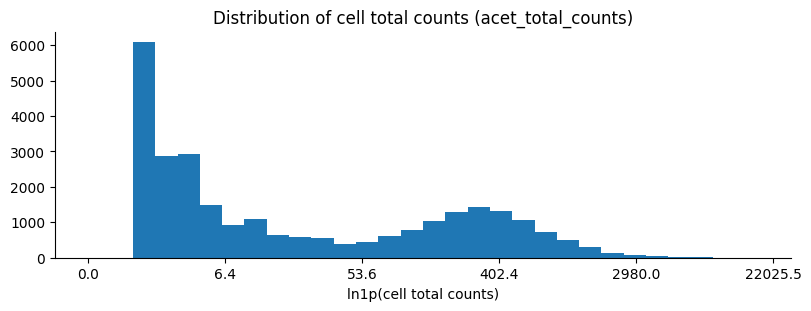

/home/aleksander-work/Skrivbord/pyproject/notebooks/src/plotting/_hist.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plw.ax.set_xticklabels(xticks)


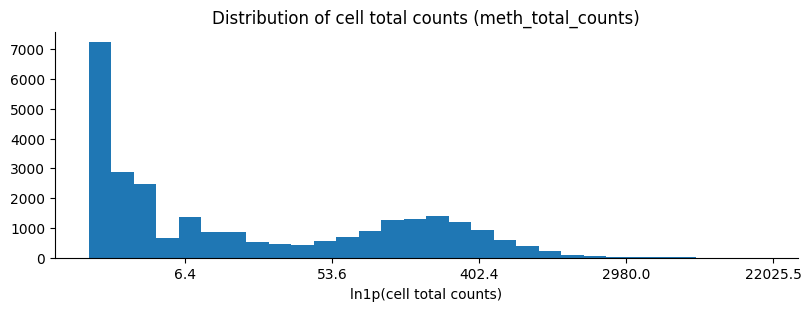

/home/aleksander-work/Skrivbord/pyproject/notebooks/src/plotting/_hist.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plw.ax.set_xticklabels(xticks)


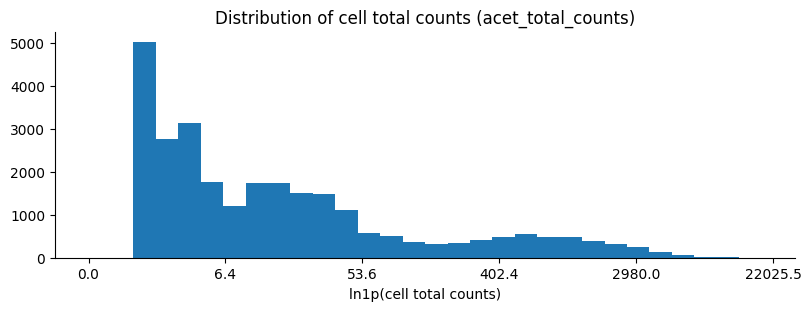

/home/aleksander-work/Skrivbord/pyproject/notebooks/src/plotting/_hist.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plw.ax.set_xticklabels(xticks)


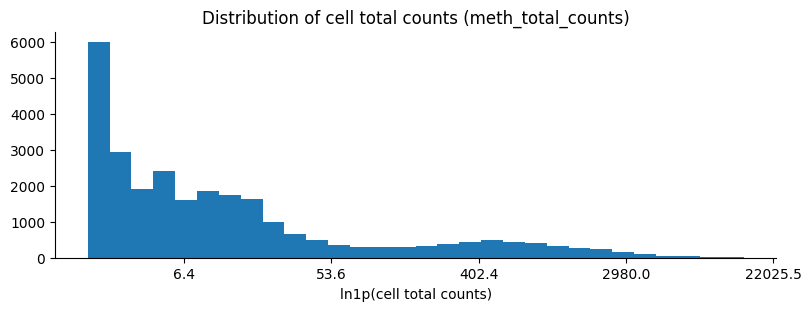

In [3]:
scit.tl.add_metadata(rep1, ['acet', 'meth'])
scit.tl.add_metadata(rep2, ['acet', 'meth'])
scit.set_defaults(figsize=(8,3))
scit.pl.counts_histogram(rep1, label_exp=True)
scit.pl.counts_histogram(rep2, label_exp=True)

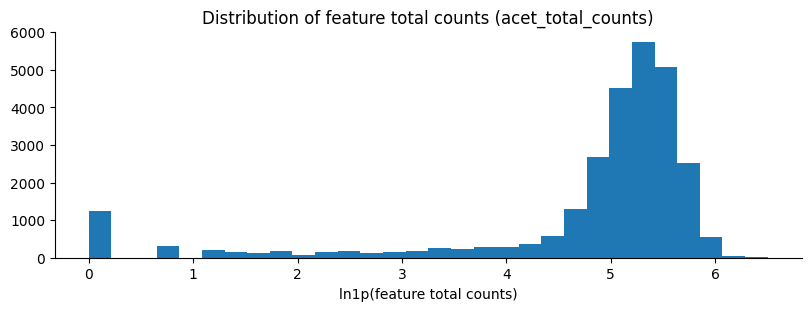

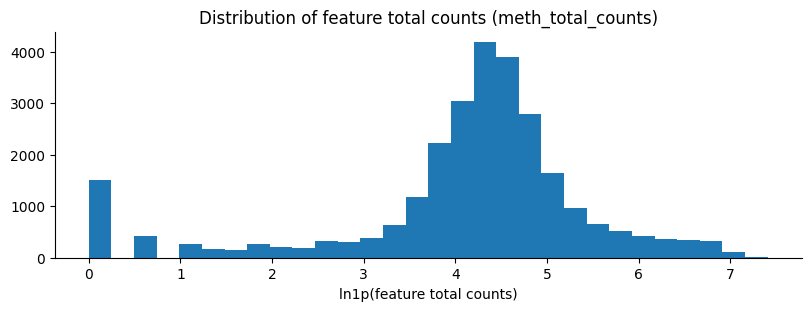

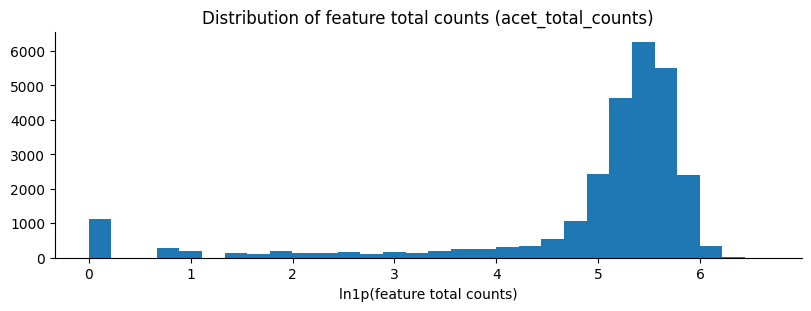

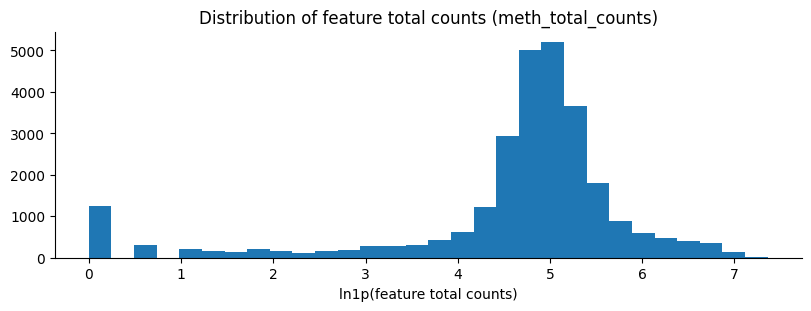

In [4]:
scit.pl.counts_histogram(rep1, hist_type='feature')
scit.pl.counts_histogram(rep2, hist_type='feature')

In [5]:
rep1 = scit.tl.filter(
    rep1, ['acet', 'meth'], 
    min_obs_counts=[40, 40], 
    max_obs_counts=[99j, 99j], 
    return_purged=True
)
rep2 = scit.tl.filter(
    rep2, ['acet', 'meth'], 
    min_obs_counts=[40, 40], 
    max_obs_counts=[99j, 99j], 
    return_purged=True
)

Info: The 99.0th percentile of obs total counts is 1806.989999999998
Info: The 99.0th percentile of obs total counts is 1172.0
Info: The 99.0th percentile of obs total counts is 3409.8800000000047
Info: The 99.0th percentile of obs total counts is 3041.0


Info: Added acet counts metadata
Info: Added meth counts metadata
Info: Added acet counts metadata
Info: Added meth counts metadata


/home/aleksander-work/Skrivbord/pyproject/notebooks/src/plotting/_hist.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plw.ax.set_xticklabels(xticks)


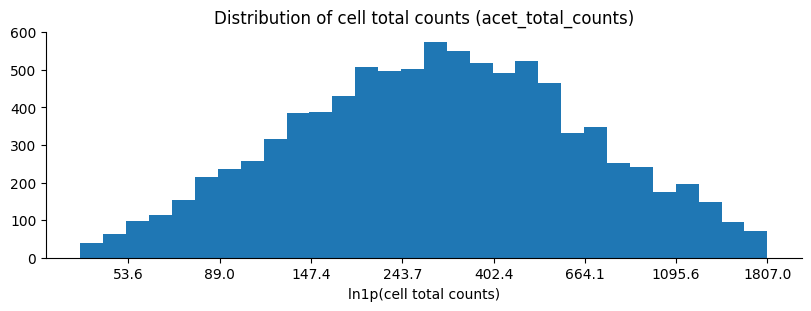

/home/aleksander-work/Skrivbord/pyproject/notebooks/src/plotting/_hist.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plw.ax.set_xticklabels(xticks)


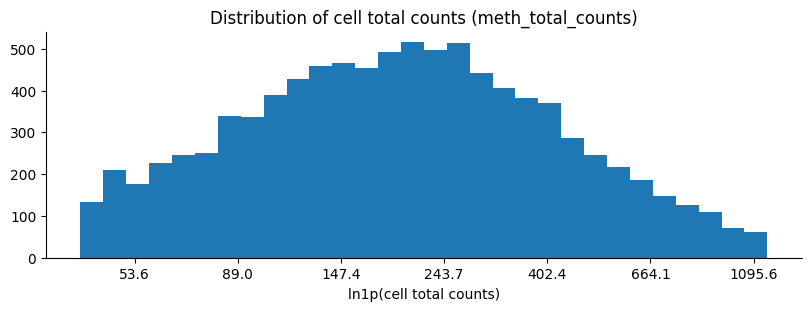

/home/aleksander-work/Skrivbord/pyproject/notebooks/src/plotting/_hist.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plw.ax.set_xticklabels(xticks)


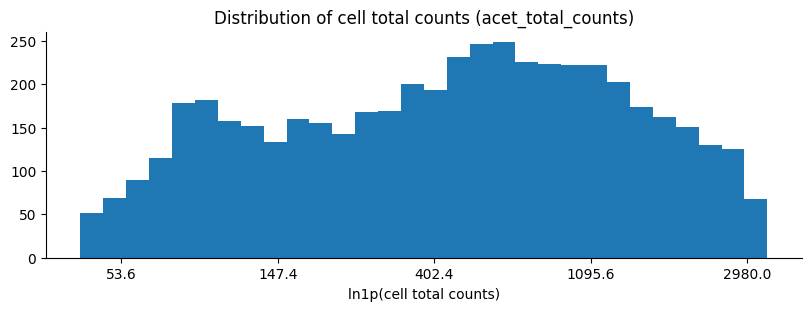

/home/aleksander-work/Skrivbord/pyproject/notebooks/src/plotting/_hist.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plw.ax.set_xticklabels(xticks)


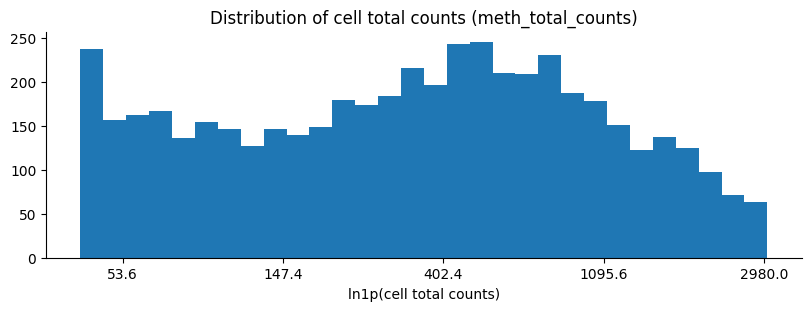

In [6]:
scit.tl.add_metadata(rep1, ['acet', 'meth'])
scit.tl.add_metadata(rep2, ['acet', 'meth'])
scit.set_defaults(figsize=(8,3))
scit.pl.counts_histogram(rep1, label_exp=True)
scit.pl.counts_histogram(rep2, label_exp=True)

In [7]:
assert np.unique([n[-1] for n in rep1.obs_names]).shape[0] == 1
assert np.unique([n[-1] for n in rep2.obs_names]).shape[0] == 1

rep1.obs['batch'] = 'batch1'
rep1.obs_names = [f"{n}R1" for n in rep1.obs_names]
rep2.obs_names = [f"{n}R2" for n in rep2.obs_names]
rep2.obs['batch'] = 'batch2'

# Same var
assert rep2.shape[1] == np.intersect1d(rep2.var_names, rep1.var_names).shape[0]

In [8]:
adata = ad.concat([rep1, rep2])
assert (adata.var_names == rep1.var_names).all()
import pandas as pd
adata.obs['batch'] = pd.Categorical(adata.obs['batch'])
adata.obs['timep'] = '14_16h'
adata.obs['timep'] = pd.Categorical(adata.obs['timep'])
adata.var = rep1.var.copy()
scit.tl.add_metadata(adata, ['acet', 'meth'])

Info: Added acet counts metadata
Info: Added meth counts metadata


In [9]:
adata=scit.tl.filter(
   adata, ['acet', 'meth'], 
    min_var_counts=[1, 1], return_purged=True
)

In [10]:
# Soft filter
scit.tl.filter(
   adata, ['acet', 'meth'], 
    min_var_counts=[15, 15]
)

Info: Adata not modified. If you want to remove excluded cells and bins, use return_purged = True or remove them manually


In [24]:
layers = ['acet', 'meth']
layer_keys = ['X_acetylation', 'X_methylation']
scit.set_defaults(figsize=(12,5))

for i in range(len(layers)):
    print(scit.em.spectral(adata, layers[i]))
    adata.obsm[layer_keys[i]] = adata.obsm['X_spectral'].copy()
    del adata.obsm['X_spectral']
    scit.tl.remove_pc(adata, layer_keys[i], 0)

[1.         0.02280125 0.0193366  0.01907469 0.0155545  0.01452342
 0.01406391 0.01329032 0.01308246 0.0130434  0.01300518 0.01299355
 0.01295244 0.01293159 0.0129037  0.01287249 0.01284702 0.01281569
 0.01281315 0.01277066 0.01274826 0.01273692 0.01271181 0.01269395
 0.01268372]
[1.         0.05508096 0.0394187  0.02496726 0.02252793 0.0204285
 0.01994142 0.01737418 0.01727749 0.01713297 0.01705451 0.01696601
 0.0169424  0.01682579 0.01679782 0.01674079 0.01669026 0.01666794
 0.01664603 0.01660084 0.01659109 0.01652878 0.01651523 0.01644778
 0.01641835]


In [25]:
np.random.seed(0)
print(scit.em.multiview_spectral(adata, ['acet', 'meth'], random_seed=22))

[1.         0.03533372 0.02606842 0.01731882 0.01635046 0.01521048
 0.01243034 0.01149831 0.01124834 0.01081186 0.01015177 0.00977613
 0.00970112 0.00968482 0.00965207 0.00961997 0.00960814 0.00958278
 0.00955122 0.00953612 0.0095308  0.00948512 0.00947322 0.00946748
 0.00946088]


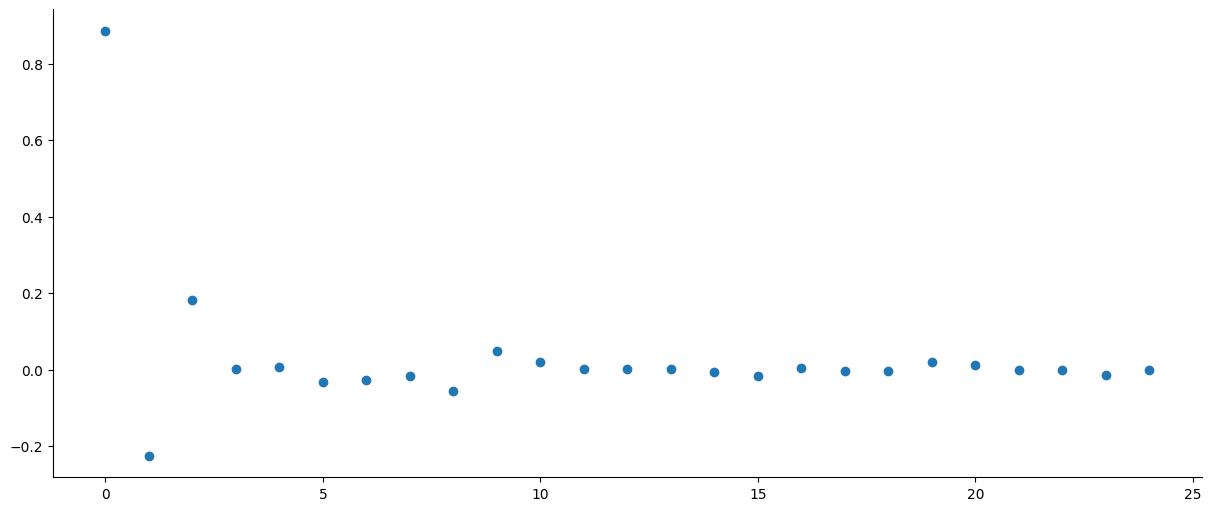

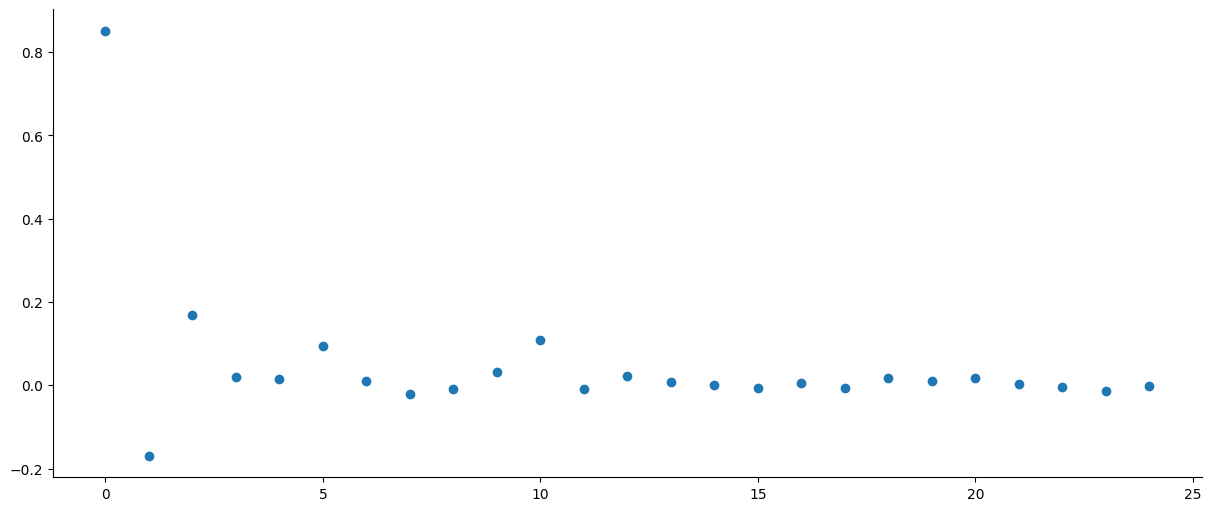

In [26]:
scit.pl.depth_corr(adata, 'X_multi_spectral', 'acet')
scit.pl.depth_corr(adata, 'X_multi_spectral', 'meth')

In [27]:
scit.tl.remove_pc(adata, 'X_multi_spectral', 0)

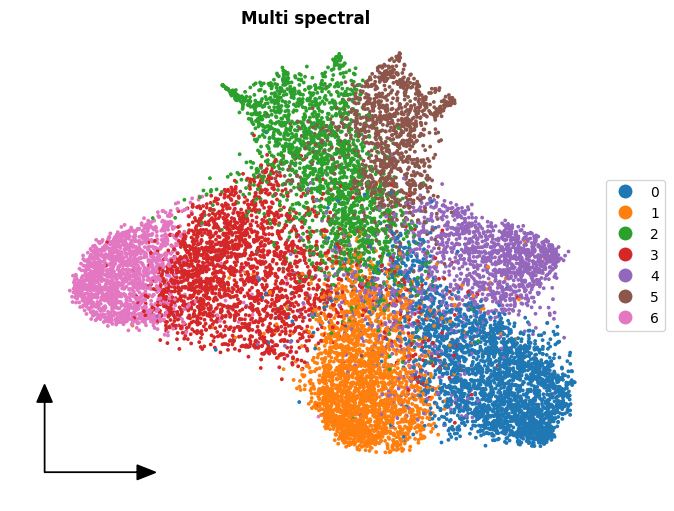

In [ ]:
scit.em.umap(adata, 'X_multi_spectral', n_neighbors=10)
scit.gr.knn(adata, 'X_multi_spectral', n_neighbors=10)
scit.gr.leiden(adata, 1, obsp_key='connectivities')
scit.set_defaults(figsize=(6,5))
scit.pl.embedding2d(adata, 'X_umap', 'leiden', title=f'Multi spectral')

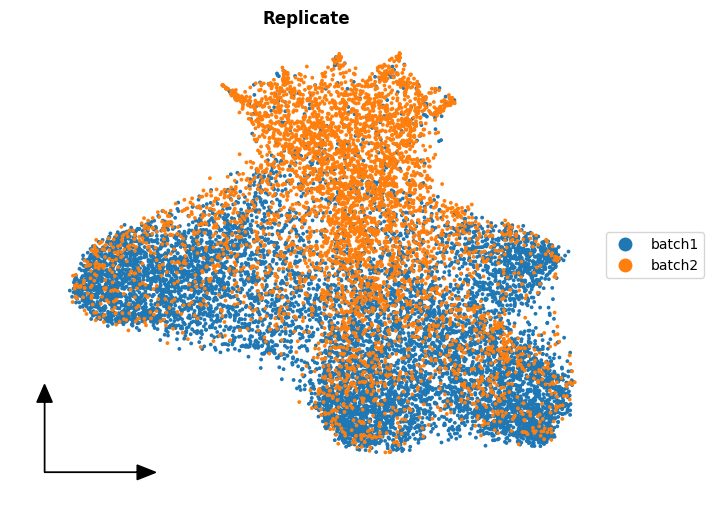

In [29]:
scit.pl.embedding2d(adata, 'X_umap', 'batch', title=f'Replicate')

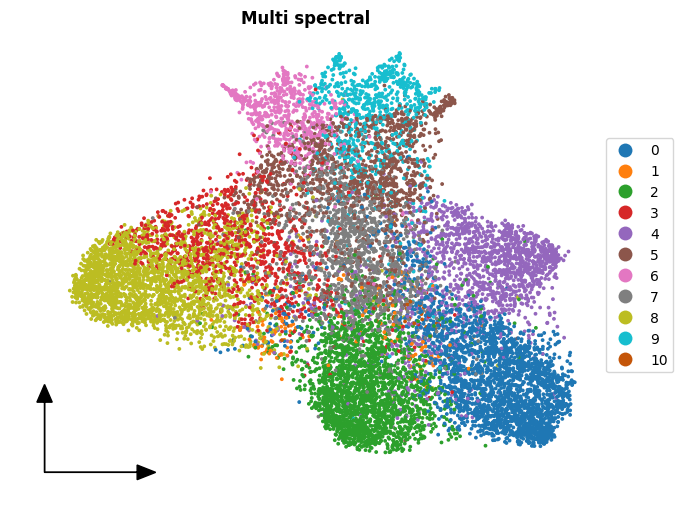

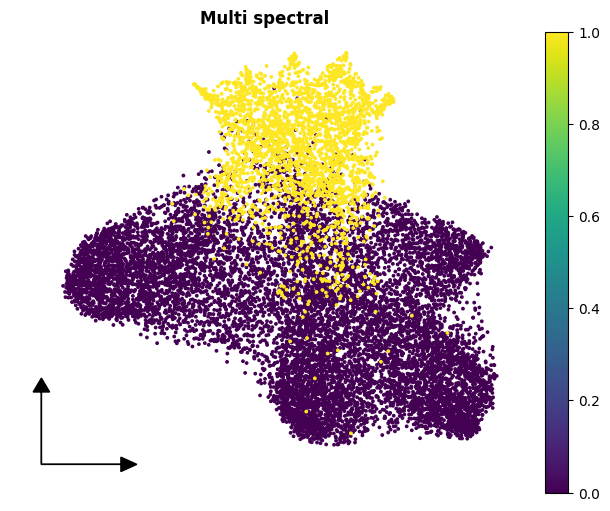

[1.         0.03565603 0.01925589 0.01637517 0.01332226 0.0124997
 0.01114292 0.01084781 0.01083178 0.01078269 0.01072123 0.01068987
 0.01067404 0.01062038 0.01059544 0.01056148 0.01054397 0.01050848
 0.01047394 0.01046338 0.01046036 0.01041976 0.01040582 0.01038542
 0.01035446]


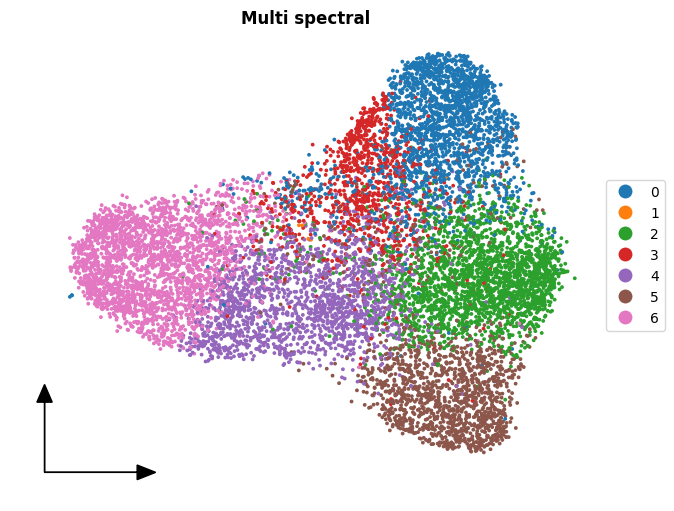

In [35]:
# Exclude subpopulations
scit.gr.leiden(adata, 1.2, obsp_key='connectivities', random_seed=2)
scit.set_defaults(figsize=(6,5))
scit.pl.embedding2d(adata, 'X_umap', 'leiden', title=f'Multi spectral')
adata.obs['exclude'] = ((adata.obs['leiden'] == 9) + (adata.obs['leiden'] == 5) + (adata.obs['leiden'] == 6))
scit.pl.embedding2d(adata, 'X_umap', 'exclude', title=f'Multi spectral')
adata = adata[adata.obs['exclude'] != 1].copy()

np.random.seed(0)
print(scit.em.multiview_spectral(adata, ['acet', 'meth'], random_seed=22))
scit.tl.remove_pc(adata, 'X_multi_spectral', 0)
scit.em.umap(adata, 'X_multi_spectral', n_neighbors=10)
scit.gr.knn(adata, 'X_multi_spectral', n_neighbors=10)
scit.gr.leiden(adata, 1, obsp_key='connectivities')
scit.set_defaults(figsize=(6,5))
scit.pl.embedding2d(adata, 'X_umap', 'leiden', title=f'Multi spectral')

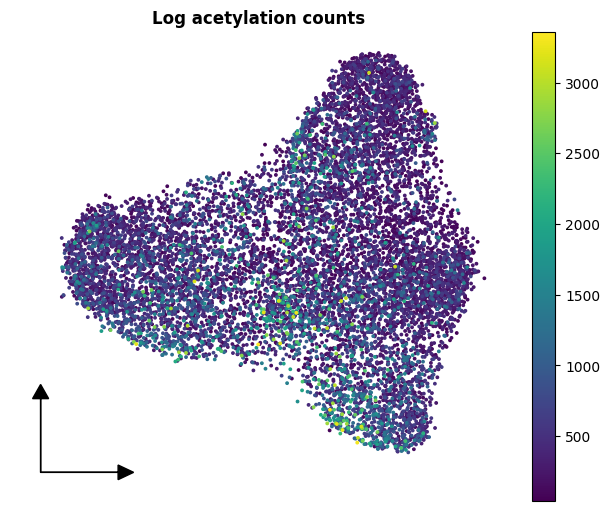

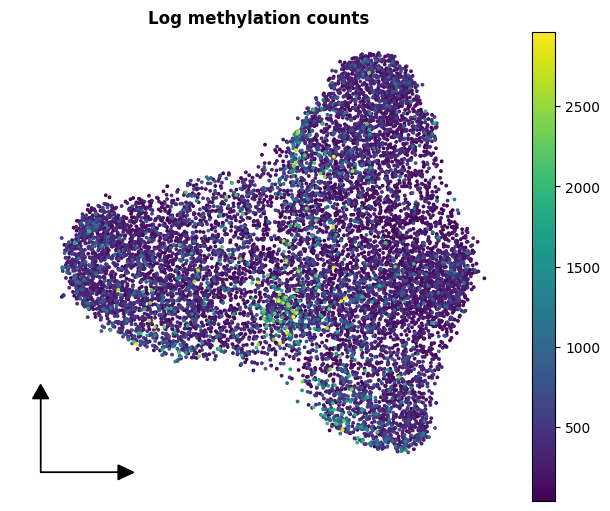

In [36]:
scit.pl.embedding2d(adata, 'X_umap', 'acet_total_counts', title='Log acetylation counts')
scit.pl.embedding2d(adata, 'X_umap', 'meth_total_counts', title='Log methylation counts')

In [37]:
adata.write_h5ad('private/data/clean_method/mutant.h5ad')